In [2]:
# Section 0: Setup
import urllib.request, zipfile, io, os, json, textwrap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 120)
# Force pandas to show regular floats instead of scientific notation
pd.set_option('display.float_format', lambda x: '%.2f' % x)


### China area codes across FAOSTAT datasets

| Code | Label | QCL (production) | TCL (trade) | TM (trade) | What it is |
|------|-------|:----------------:|:-----------:|:----------:|------------|
| **41** | China, mainland | ✅ | ✅ | ✅ | Mainland only — **the entity used** |
| 351 | China | ✅ | ✅ | ✅ | Aggregate: mainland + Taiwan + Hong Kong + Macao |
| 357 | China (mainland + Taiwan) | — | ✅ | ✅ | Aggregate: mainland + Taiwan (trade domains only) |
| 214 | China, Taiwan Province of | ✅ | ✅ | ✅ | Taiwan as a standalone territory |
| 96 | China, Hong Kong SAR | ✅ | ✅ | ✅ | Hong Kong as a standalone territory |
| 128 | China, Macao SAR | ✅ | ✅ | ✅ | Macao as a standalone territory |

**Why only code 41 (China, mainland):**

- **No double-counting** — 351 and 357 already contain the mainland, so keeping them alongside 41 counts mainland output/trade twice (the inflation bug seen in the production ranking).
- **Cross-dataset consistency** — production (QCL) is divided by trade (TCL/TM), so "China" must be the *same entity* in every file. Code 41 is the only China code present cleanly in all three; the aggregates differ by domain (351 everywhere, 357 trade-only).
- **Trade realism** — 351 bundles in Hong Kong, a major entrepôt whose re-export flows would inflate "China's" trade with goods that never originated on the mainland.
- **Stated scope** — 41 is mainland-only (excludes Taiwan 214, Hong Kong 96, Macao 128). Methodology note: **"China" = mainland, FAO code 41.**

##### Note on why code 30 export analysis with code 27 production analysis was needed:
1. The code 30 here is a Rice, paddy (rice milled equivalent) and it was necessary to do this analysis to understand what FAOSTATS reports for Rice (code 27) production vs Rice, paddy (rice milled equivalent) (code 30) which is an ~equivalent of~ code 28, 31, 32 and 29 

2. The layer of check was this:
Reconciliation layer — your export build vs code 30 (both trade): 28÷0.77 + 31÷0.67 compared to code30÷0.67. This is the real check — two routes to the same "total rice exports" number. They should be close, with code 30 slightly higher (it includes broken rice and milled-husked that your 28+31 omits). This validates your conversion.

3. The milled_to_paddy_factor of 0.67 comes from 
Reference PDF: https://openknowledge.fao.org/server/api/core/bitstreams/63b8626c-7019-4f8c-a961-e975e7f9e285/content
(Page 723) 
This conversion exists since production is not traded as is, it is at times the byproducts or broken into crops as seen in the PDF, 
Can be navigated from: https://openknowledge.fao.org/home

In [3]:
# Section 0: Data principles, encoded as config so every downstream calc references the same
# assumptions instead of re-deciding them inline.
CONFIG = {
    # --- Scope for production ---
    'crop_item_code': 27,        # FAOSTAT Item Code for Rice (verified in Section 1)
    'crop_name': 'Rice',

   # --- Scope for trade ----
    'trade_crop_item_code': 30,
    'milled_to_paddy_factor':0.67,
 

    # --- Drop Area codes----
    # Excluding regional/continental aggregates (<5000)
    # Table above has an explaination about how China's area codes are represented in the FAOSTAT datset
    'aggregate_code_cutoff': 5000,
    'exclude_area_codes': [351, 357,214,96,128],
}

print(json.dumps({k: v for k, v in CONFIG.items() if k != 'water_stress_bins'}, indent=2, default=str))


{
  "crop_item_code": 27,
  "crop_name": "Rice",
  "trade_crop_item_code": 30,
  "milled_to_paddy_factor": 0.67,
  "aggregate_code_cutoff": 5000,
  "exclude_area_codes": [
    351,
    357,
    214,
    96,
    128
  ]
}


Section 1a: Rice production — QCL bulk download

In [4]:
# Section 1a: QCL bulk download (Production: Crops and livestock products)
BULK_URL = 'https://bulks-faostat.fao.org/production/Production_Crops_Livestock_E_All_Data_(Normalized).zip'
if not os.path.exists('qcl_bulk.zip'):
    print('Downloading QCL bulk file...')
    urllib.request.urlretrieve(BULK_URL, 'qcl_bulk.zip')

with zipfile.ZipFile('qcl_bulk.zip') as z:
    csv_name = [n for n in z.namelist() if n.endswith('.csv') and 'Flags' not in n
                and 'ItemCodes' not in n and 'AreaCodes' not in n][0]
    print(f'Reading {csv_name}...')
    qcl_all = pd.read_csv(z.open(csv_name), encoding='latin-1', low_memory=False)

    item_csv = [n for n in z.namelist() if 'ItemCodes' in n][0]
    item_codes = pd.read_csv(z.open(item_csv), encoding='latin-1')

    area_csv = [n for n in z.namelist() if 'AreaCodes' in n][0]
    area_codes = pd.read_csv(z.open(area_csv), encoding='latin-1')

print(f'Full QCL: {len(qcl_all):,} rows')

Reading Production_Crops_Livestock_E_All_Data_(Normalized).csv...
Full QCL: 4,209,110 rows


In [5]:
rice_matches = item_codes[item_codes['Item'].str.contains('Rice', case=False, na=False)][['Item Code', 'Item']]
print(rice_matches.to_string(index=False))

exact = rice_matches[rice_matches['Item'].str.fullmatch('Rice', case=False)]
if len(exact):
    CONFIG['crop_item_code'] = int(exact.iloc[0]['Item Code'])
else:
    print("No exact 'Rice' match in the lookup — check the table above and set CONFIG['crop_item_code'] manually.")
    CONFIG['crop_item_code'] = int(rice_matches.iloc[0]['Item Code'])  # best-effort fallback

print(f"Using Item Code {CONFIG['crop_item_code']} for Rice")

Item Code Item
       27 Rice
Using Item Code 27 for Rice


In [6]:
# Section 1c: filter to Rice Production (tonnes), then drop regional/continental aggregates (< 5000)
# AND the China aggregates/territories (keeping mainland 41 only, per CONFIG).
# Area Code isin() cast to str on both sides — the dtype mismatch here was the bug fixed in the
# original notebook's Section 3; keeping the cast explicit rather than trusting pandas to infer it.
qcl_rice = qcl_all[(qcl_all['Item Code'] == CONFIG['crop_item_code']) & (qcl_all['Element'] == 'Production')].copy()
print(f"Rice, Production element: {len(qcl_rice):,} rows, unit(s): {qcl_rice['Unit'].unique()}")
# print(qcl_rice.head())

# build the valid-country set: below the aggregate cutoff AND not an excluded China code
area_code_exclude = area_codes[
    (area_codes['Area Code'] < CONFIG['aggregate_code_cutoff'])
    & (~area_codes['Area Code'].isin(CONFIG['exclude_area_codes']))
]
valid_country_codes = set(area_code_exclude['Area Code'].astype(str))

qcl_rice = qcl_rice[qcl_rice['Area Code'].astype(str).isin(valid_country_codes)].copy()
print(f"After dropping aggregates + doubly counted codes (for China): {len(qcl_rice):,} rows, {qcl_rice['Area'].nunique()} countries")
# print(qcl_rice.head())

rice_by_area_year = qcl_rice.groupby(['Area', 'Area Code', 'Year'])['Value'].sum().reset_index(name='production_t')

Rice, Production element: 9,708 rows, unit(s): ['t']
After dropping aggregates + doubly counted codes (for China): 7,544 rows, 143 countries


In [7]:
rice_by_area_year

,Area,Area Code,Year,production_t
0,Afghanistan,2,1961,319000.00
1,Afghanistan,2,1962,319000.00
2,Afghanistan,2,1963,319000.00
3,Afghanistan,2,1964,380000.00
4,Afghanistan,2,1965,380000.00
...,...,...,...,...
7539,Zimbabwe,181,2020,192.00
7540,Zimbabwe,181,2021,2908.00
7541,Zimbabwe,181,2022,539.00
7542,Zimbabwe,181,2023,539.00


In [8]:
world_production_over_year = rice_by_area_year.groupby('Year')['production_t'].sum().reset_index()
print(world_production_over_year)

    Year  production_t
0   1961  213069031.00
1   1962  223766003.00
2   1963  244444925.00
3   1964  260075174.00
4   1965  251074029.00
..   ...           ...
59  2020  769854053.78
60  2021  789501998.86
61  2022  777062081.24
62  2023  803284082.38
63  2024  818174842.58

[64 rows x 2 columns]


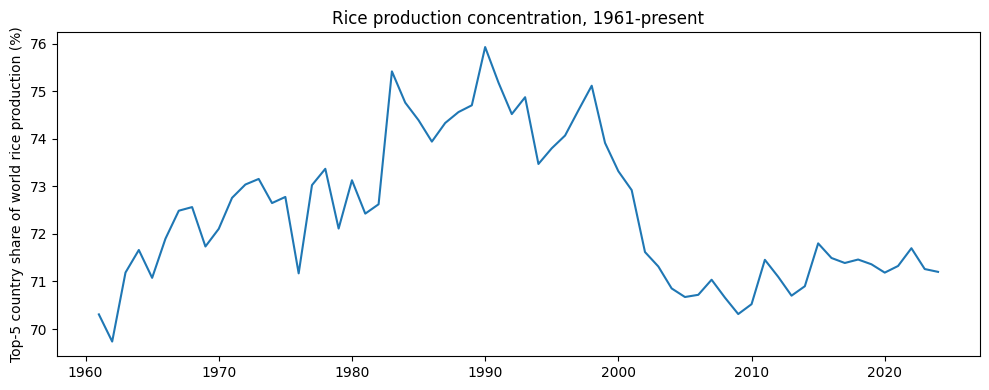

Latest top-5 share: 71.2%


In [9]:
# Full-history concentration trend (top-5 share of world production, year by year) — same metric
# as the original notebook's Section 4, recomputed here for Rice alone.
by_year_rank = rice_by_area_year.copy()
by_year_rank['rank'] = by_year_rank.groupby('Year')['production_t'].rank(ascending=False, method='min')

global_total_by_year = rice_by_area_year.groupby('Year')['production_t'].sum().reset_index(name='global_total')
top5_by_year = (by_year_rank[by_year_rank['rank'] <= 5]
                .groupby('Year')['production_t'].sum().reset_index(name='top5_total'))
concentration = top5_by_year.merge(global_total_by_year, on='Year')
concentration['top5_share_pct'] = concentration['top5_total'] / concentration['global_total'] * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(concentration['Year'], concentration['top5_share_pct'])
ax.set_ylabel('Top-5 country share of world rice production (%)')
ax.set_title('Rice production concentration, 1961-present')
plt.tight_layout(); plt.show()

print(f"Latest top-5 share: {concentration.sort_values('Year').iloc[-1]['top5_share_pct']:.1f}%")


#### Analysing the production (Total and Avg) for countries over a period of 2000-2024

In [10]:
#This is the total production analysis
rice_production_2000_2024 = (
    rice_by_area_year[
        (rice_by_area_year['Year'] >= 2000) &
        (rice_by_area_year['Year'] <= 2024)
    ]
    .groupby('Area')['production_t']
    .sum()
    .reset_index()
    .sort_values('production_t', ascending=False)
)

print(rice_production_2000_2024)

                                 Area  production_t
23                    China, mainland 4944787500.00
59                              India 3949568648.52
60                          Indonesia 1391403356.54
7                          Bangladesh 1209116494.14
138                          Viet Nam 1004997339.59
..                                ...           ...
99                             Poland          0.00
30                             Cyprus          0.00
111                          Slovakia          0.00
112                          Slovenia          0.00
107  Saint Vincent and the Grenadines          0.00

[141 rows x 2 columns]


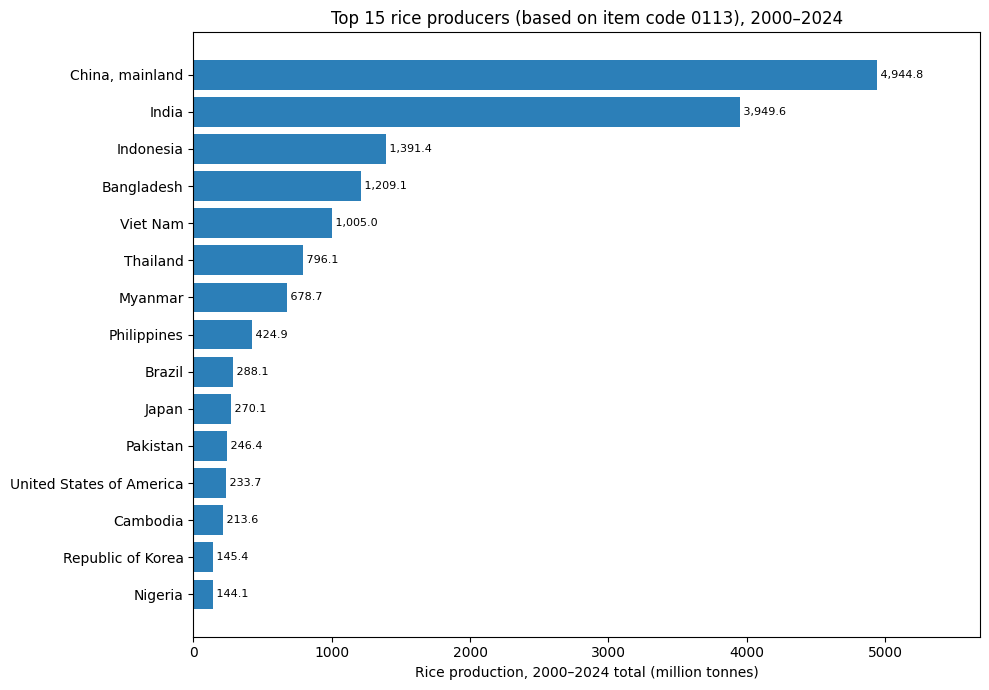

In [11]:
#Plotting the above data in bar-chart format
top = rice_production_2000_2024.nlargest(15, 'production_t').sort_values('production_t')

plt.figure(figsize=(10, 7))
plt.barh(top['Area'], top['production_t'] / 1e6, color="#2C7FB8")
plt.xlabel("Rice production, 2000–2024 total (million tonnes)")
plt.title("Top 15 rice producers (based on item code 0113), 2000–2024")

for y, v in enumerate(top['production_t'] / 1e6):
    plt.text(v, y, f" {v:,.1f}", va='center', fontsize=8)

plt.margins(x=0.15)
plt.tight_layout()
plt.show()

### Insights here:

**Two giants dominate.** China (4,944.8 Mt) and India (3,949.6 Mt) together produced ~8,894 Mt over 2000–2024 — more than the next 13 countries on this chart *combined*. Rice production is heavily top-heavy, not evenly spread.

**A steep drop after the top two.** #3 Indonesia (1,391.4 Mt) produces barely a quarter of China's output, and the chart falls off fast from there — Bangladesh (1,209.1) and Viet Nam (1,005.0) round out the only other billion-tonne-plus producers. Everyone below Thailand is under 800 Mt.

**Asia owns rice.** 13 of the top 15 producers are Asian; only Brazil (#9, 288.1 Mt) and the USA (#12, 233.7 Mt) break the pattern, and both sit far down the list. Rice production is geographically concentrated in South, Southeast, and East Asia.

**A long, flat tail.** From Myanmar (678.7 Mt) down to Nigeria (144.1 Mt), the bars cluster tightly at low values — a wide field of modest producers with no standout among them. Africa's largest rice grower (Nigeria) makes this list only at the very bottom.

### Takeaway
World rice production rests on a handful of Asian giants — China and India alone are the
backbone — with a steep cliff after the top few and a long tail of smaller producers. This
concentration matters for food security: output is dominated by countries that (as the
export analysis shows) mostly consume domestically, so the world's largest producers are
not its largest exporters.

#### Analysing, how does each countries production look at the global level by adding a pct_share_production and rank to each country solely for production
  This is essential for Section 2

In [12]:
# Add each country's share of total world cotton production, 2000-2024
rice_production_2000_2024['pct_share_production'] = (
    rice_production_2000_2024['production_t']
    / rice_production_2000_2024['production_t'].sum()
    * 100
)

# Re-sort and assign rank
rice_production_2000_2024 = (
    rice_production_2000_2024
    .sort_values('production_t', ascending=False)
    .reset_index(drop=True)
)

rice_production_2000_2024['rank'] = (
    rice_production_2000_2024.index + 1
)

print(rice_production_2000_2024)

                                 Area  production_t  pct_share_production  rank
0                     China, mainland 4944787500.00                 28.20     1
1                               India 3949568648.52                 22.52     2
2                           Indonesia 1391403356.54                  7.93     3
3                          Bangladesh 1209116494.14                  6.89     4
4                            Viet Nam 1004997339.59                  5.73     5
..                                ...           ...                   ...   ...
136                        Luxembourg          0.00                  0.00   137
137                           Germany          0.00                  0.00   138
138                           Belgium          0.00                  0.00   139
139                           Finland          0.00                  0.00   140
140  Saint Vincent and the Grenadines          0.00                  0.00   141

[141 rows x 4 columns]


In [13]:
#This is the average production 
avg_rice_production_2000_2024 = (
    rice_by_area_year[
        (rice_by_area_year['Year'] >= 2000) &
        (rice_by_area_year['Year'] <= 2024)
    ]
    .groupby('Area')['production_t']
    .mean()
    .reset_index()
    .sort_values('production_t', ascending=False)
)

print(avg_rice_production_2000_2024)

                                 Area  production_t
23                    China, mainland  197791500.00
59                              India  157982745.94
60                          Indonesia   55656134.26
7                          Bangladesh   48364659.77
138                          Viet Nam   40199893.58
..                                ...           ...
99                             Poland          0.00
30                             Cyprus          0.00
111                          Slovakia          0.00
112                          Slovenia          0.00
107  Saint Vincent and the Grenadines          0.00

[141 rows x 2 columns]


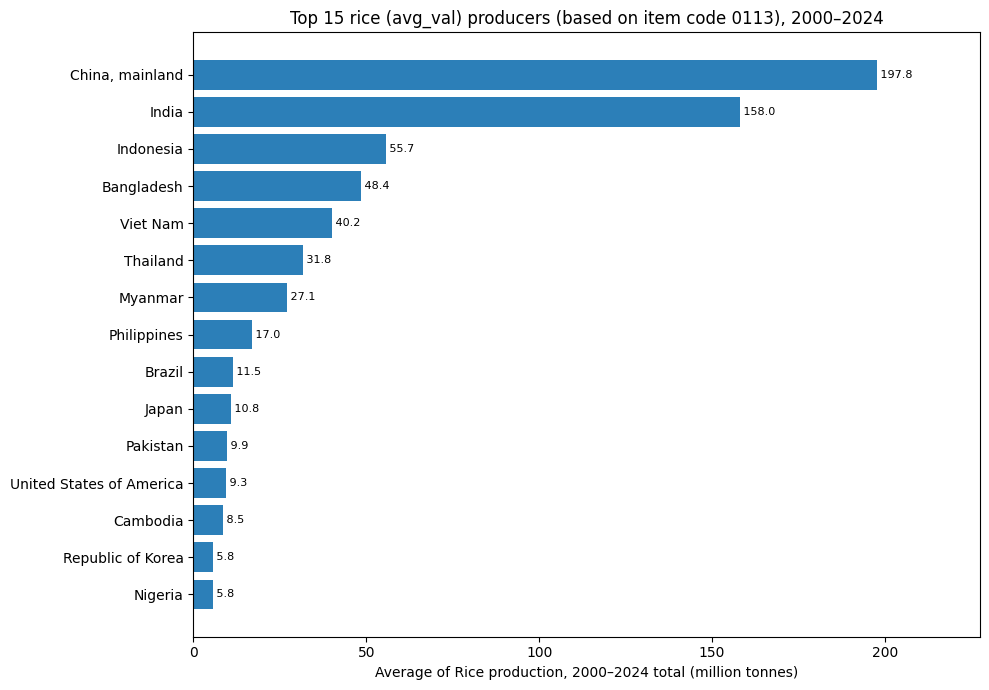

In [14]:
#Plotting the above data in bar-chart format
top = avg_rice_production_2000_2024.nlargest(15, 'production_t').sort_values('production_t')

plt.figure(figsize=(10, 7))
plt.barh(top['Area'], top['production_t'] / 1e6, color="#2C7FB8")
plt.xlabel("Average of Rice production, 2000–2024 total (million tonnes)")
plt.title("Top 15 rice (avg_val) producers (based on item code 0113), 2000–2024")

for y, v in enumerate(top['production_t'] / 1e6):
    plt.text(v, y, f" {v:,.1f}", va='center', fontsize=8)

plt.margins(x=0.15)
plt.tight_layout()
plt.show()

In [15]:
#Adding the world percentage values and ranks in terms of average production 
# This should almost match with teh total production above
avg_rice_production_2000_2024['pct_of_world'] = (
    avg_rice_production_2000_2024['production_t']
    / avg_rice_production_2000_2024['production_t'].sum() * 100
)

avg_rice_production_2000_2024 = avg_rice_production_2000_2024.reset_index(drop=True)
avg_rice_production_2000_2024['rank'] = avg_rice_production_2000_2024.index + 1

print(avg_rice_production_2000_2024)

                                 Area  production_t  pct_of_world  rank
0                     China, mainland  197791500.00         28.19     1
1                               India  157982745.94         22.52     2
2                           Indonesia   55656134.26          7.93     3
3                          Bangladesh   48364659.77          6.89     4
4                            Viet Nam   40199893.58          5.73     5
..                                ...           ...           ...   ...
136                            Poland          0.00          0.00   137
137                            Cyprus          0.00          0.00   138
138                          Slovakia          0.00          0.00   139
139                          Slovenia          0.00          0.00   140
140  Saint Vincent and the Grenadines          0.00          0.00   141

[141 rows x 4 columns]


<!-- ### How much of the rice is exported outside? And export/import analysis into one
1. Export share of production — How much of what it grows does it ship out?
Formula: export_share = export_qty ÷ production (done)

2. Net trade position - Is it a net seller or net buyer? (To do?)
Formula: net_exports = export_qty − import_qty  = 36,160.97 − 0.13 ≈ 36,160.84 t

3. apparent_supply = production − export_qty + import_qty (to-do?)

4. Self sufficieny ratio (SSR) (to-do?)
SSR = production ÷ (production − export_qty + import_qty)
SSR > 1 means the country grows more than it consumes (net exporter); SSR < 1 means it leans on imports. -->

 ### Section 1b: TCL data analysis: How much of produced rice enters international trade?

In [16]:
# TCL bulk download (Trade: Crops and livestock products)
BULK_URL = 'https://bulks-faostat.fao.org/production/Trade_CropsLivestock_E_All_Data_(Normalized).zip'
if not os.path.exists('tcl_bulk.zip'):
    print('Downloading TCL bulk file (~261 MB, a few minutes)...')
    urllib.request.urlretrieve(BULK_URL, 'tcl_bulk.zip')

with zipfile.ZipFile('tcl_bulk.zip') as z:
    csv_name = [n for n in z.namelist() if n.endswith('.csv') and 'Flags' not in n
                and 'ItemCodes' not in n and 'AreaCodes' not in n
                and 'Elements' not in n][0]
    print(f'Reading {csv_name}...')
    tcl_all = pd.read_csv(z.open(csv_name), encoding='latin-1', low_memory=False)

    item_csv = [n for n in z.namelist() if 'ItemCodes' in n][0]
    tcl_item_codes = pd.read_csv(z.open(item_csv), encoding='latin-1')

    area_csv = [n for n in z.namelist() if 'AreaCodes' in n][0]
    tcl_area_codes = pd.read_csv(z.open(area_csv), encoding='latin-1')

print(f'Full TCL: {len(tcl_all):,} rows')

Reading Trade_CropsLivestock_E_All_Data_(Normalized).csv...
Full TCL: 17,143,873 rows


In [17]:
print(tcl_all.head())

   Area Code Area Code (M49)         Area  Item Code Item Code (CPC)               Item  Element Code  \
0          2            '004  Afghanistan        221          '01371  Almonds, in shell          5610   
1          2            '004  Afghanistan        221          '01371  Almonds, in shell          5610   
2          3            '008      Albania        221          '01371  Almonds, in shell          5610   
3          4            '012      Algeria        221          '01371  Almonds, in shell          5610   
4          3            '008      Albania        221          '01371  Almonds, in shell          5610   

           Element  Year Code  Year Unit  Value Flag                                            Note  
0  Import quantity       2014  2014    t  34.46    X  Estimated data using trading partners database  
1  Import quantity       2015  2015    t  75.50    X  Estimated data using trading partners database  
2  Import quantity       1996  1996    t  87.00    A        

### Section 1b (1): Using code Item code 30 specifically as layer 1 for analysis: (Rice from QCL to rice in TCL)
This analysis isnt fair comparision since the code deosnt give the full picture, and the code 30 is an aggregate developed by Code 30 — "Rice; paddy (rice milled equivalent)" — is FAO's own pre-computed aggregate that does exactly the conversion done (using CODE 28 AND 31), but in the opposite direction.
#### milled-eq → paddy-eq



In [18]:
# filter to Rice Export (tonnes), then drop regional/continental aggregates (< 5000)
# AND the China aggregates/territories (keeping mainland 41 only, per CONFIG).
tcl_rice = tcl_all[(tcl_all['Item Code'] == CONFIG['trade_crop_item_code']) & (tcl_all['Element'] == 'Export quantity')].copy()
print(f"Rice, Export element: {len(tcl_rice):,} rows, unit(s): {tcl_rice['Unit'].unique()}")

# --- convert code 30 (milled-equivalent) to paddy-equivalent ---
# code 30 is reported in milled-rice weight; divide by the milling factor to lift to paddy terms
# so it's comparable to QCL production (code 27, paddy).
tcl_rice['exported_t'] = tcl_rice['Value'] / CONFIG['milled_to_paddy_factor']   # 0.67

# build the valid-country set: below the aggregate cutoff AND not an excluded China code
area_code_exclude = area_codes[
    (area_codes['Area Code'] < CONFIG['aggregate_code_cutoff'])
    & (~area_codes['Area Code'].isin(CONFIG['exclude_area_codes']))
]
valid_country_codes = set(area_code_exclude['Area Code'].astype(str))

tcl_rice = tcl_rice[tcl_rice['Area Code'].astype(str).isin(valid_country_codes)].copy()
print(f"After dropping aggregates + doubly counted codes (for China): {len(tcl_rice):,} rows, {tcl_rice['Area'].nunique()} countries")

# aggregate the PADDY-EQUIVALENT tonnes per country-year
rice_by_area_year_traded = (tcl_rice
    .groupby(['Area', 'Area Code', 'Year'])['exported_t']
    .sum()
    .reset_index(name='exported_t'))

Rice, Export element: 12,620 rows, unit(s): ['t']
After dropping aggregates + doubly counted codes (for China): 9,487 rows, 203 countries


In [19]:
rice_by_area_year_traded

,Area,Area Code,Year,exported_t
0,Afghanistan,2,2003,101.49
1,Afghanistan,2,2004,167.70
2,Afghanistan,2,2005,147.76
3,Afghanistan,2,2006,0.09
4,Afghanistan,2,2007,13.43
...,...,...,...,...
9482,Zimbabwe,181,2016,1970.04
9483,Zimbabwe,181,2017,1075.22
9484,Zimbabwe,181,2018,1.04
9485,Zimbabwe,181,2019,0.21


In [20]:
# World rice traded per year in tonnes
world_trade_over_year = rice_by_area_year_traded.groupby('Year')['exported_t'].sum().reset_index()
print(world_trade_over_year)


    Year  exported_t
0   1961  9206728.51
1   1962  9829885.37
2   1963 11663705.30
3   1964 12146119.48
4   1965 11945231.42
..   ...         ...
59  2020 67811708.64
60  2021 77778113.01
61  2022 85290212.81
62  2023 80245644.01
63  2024 89239803.03

[64 rows x 2 columns]


#### Which countries exported the most rice (code 30) over the entire 2000–2024 period? 
Note: Top exporters, shown below are based on the the FAOSTAT Rice; paddy (rice milled equivalent) ('F0030 or Item code 30) trade classification.

In [21]:
#Total exports of rice (code 30) between 2000-2024
rice_exports_2000_2024 = (
    rice_by_area_year_traded[
        (rice_by_area_year_traded['Year'] >= 2000) &
        (rice_by_area_year_traded['Year'] <= 2024)
    ]
    .groupby('Area')['exported_t']
    .sum()
    .reset_index()
    .sort_values('exported_t', ascending=False)
)

print(rice_exports_2000_2024)


                         Area   exported_t
81                      India 334763054.16
176                  Thailand 320523353.33
195                  Viet Nam 209790313.16
133                  Pakistan 130808597.52
190  United States of America 114206704.73
..                        ...          ...
179                     Tonga         0.09
55                    Eritrea         0.04
72                 Guadeloupe         0.00
111                Martinique         0.00
148                  RÃ©union         0.00

[199 rows x 2 columns]


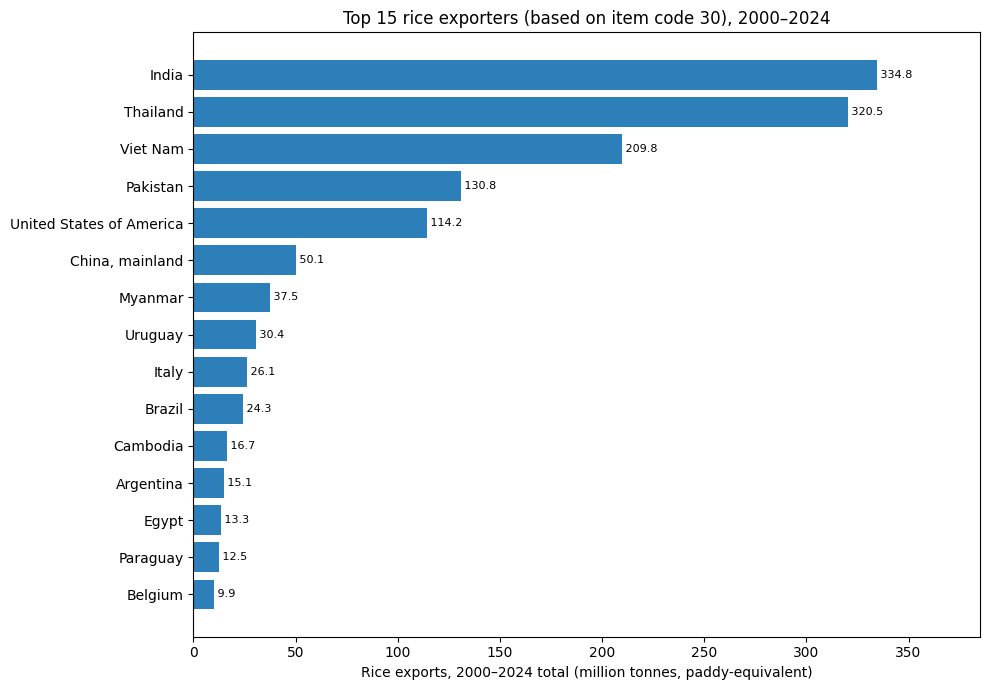

In [22]:
#Plotting the above data in bar chart
top = rice_exports_2000_2024.nlargest(15, 'exported_t').sort_values('exported_t')

plt.figure(figsize=(10, 7))
plt.barh(top['Area'], top['exported_t'] / 1e6, color="#2C7FB8")
plt.xlabel("Rice exports, 2000–2024 total (million tonnes, paddy-equivalent)")
plt.title("Top 15 rice exporters (based on item code 30), 2000–2024")

for y, v in enumerate(top['exported_t'] / 1e6):
    plt.text(v, y, f" {v:,.1f}", va='center', fontsize=8)

plt.margins(x=0.15)
plt.tight_layout()
plt.show()

### Section 1b (1.2): Percentage and rank analysis for code 30

In [23]:
# Add each country's share of total world cotton production, 2000-2024
rice_exports_2000_2024['pct_share_export'] = (
    rice_exports_2000_2024['exported_t']
    / rice_exports_2000_2024['exported_t'].sum()
    * 100
)

# Re-sort and assign rank
rice_exports_2000_2024 = (
    rice_exports_2000_2024
    .sort_values('exported_t', ascending=False)
    .reset_index(drop=True)
)

rice_exports_2000_2024['rank'] = (
    rice_exports_2000_2024.index + 1
)

print(rice_exports_2000_2024)


                         Area   exported_t  pct_share_export  rank
0                       India 334763054.16             23.09     1
1                    Thailand 320523353.33             22.11     2
2                    Viet Nam 209790313.16             14.47     3
3                    Pakistan 130808597.52              9.02     4
4    United States of America 114206704.73              7.88     5
..                        ...          ...               ...   ...
194                     Tonga         0.09              0.00   195
195                   Eritrea         0.04              0.00   196
196                Guadeloupe         0.00              0.00   197
197                Martinique         0.00              0.00   198
198                  RÃ©union         0.00              0.00   199

[199 rows x 4 columns]


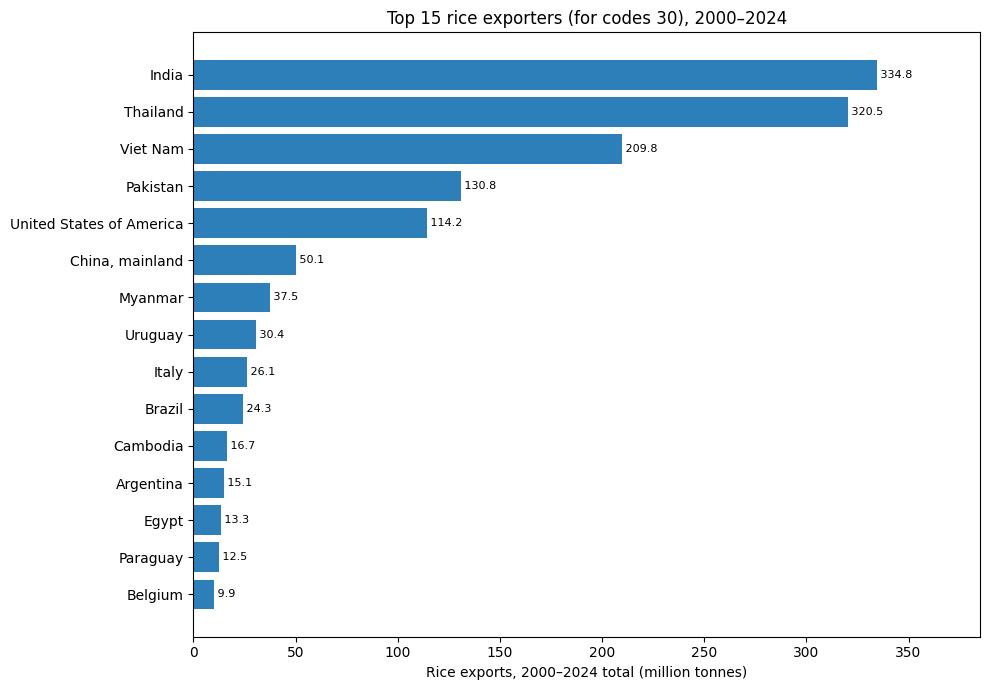

In [24]:
#Plotting the above in bar chart
top = rice_exports_2000_2024.nlargest(15, 'exported_t').sort_values('exported_t')

plt.figure(figsize=(10, 7))
plt.barh(top['Area'], top['exported_t'] / 1e6, color="#2C7FB8")
plt.xlabel("Rice exports, 2000–2024 total (million tonnes)")
plt.title("Top 15 rice exporters (for codes 30), 2000–2024")

for y, v in enumerate(top['exported_t'] / 1e6):
    plt.text(v, y, f" {v:,.1f}", va='center', fontsize=8)

plt.margins(x=0.15)
plt.tight_layout()
plt.show()

In [25]:
#Average exports of rice (code 27) between 2000-2024
average_rice_exports_2000_2024 = (
    rice_by_area_year_traded[
        (rice_by_area_year_traded['Year'] >= 2000) &
        (rice_by_area_year_traded['Year'] <= 2024)
    ]
    .groupby('Area')['exported_t']
    .mean()
    .reset_index()
    .sort_values('exported_t', ascending=False)
)

print(average_rice_exports_2000_2024)


                         Area  exported_t
81                      India 13390522.17
176                  Thailand 12820934.13
195                  Viet Nam  8391612.53
133                  Pakistan  5232343.90
190  United States of America  4568268.19
..                        ...         ...
179                     Tonga        0.03
55                    Eritrea        0.02
111                Martinique        0.00
72                 Guadeloupe        0.00
148                  RÃ©union        0.00

[199 rows x 2 columns]


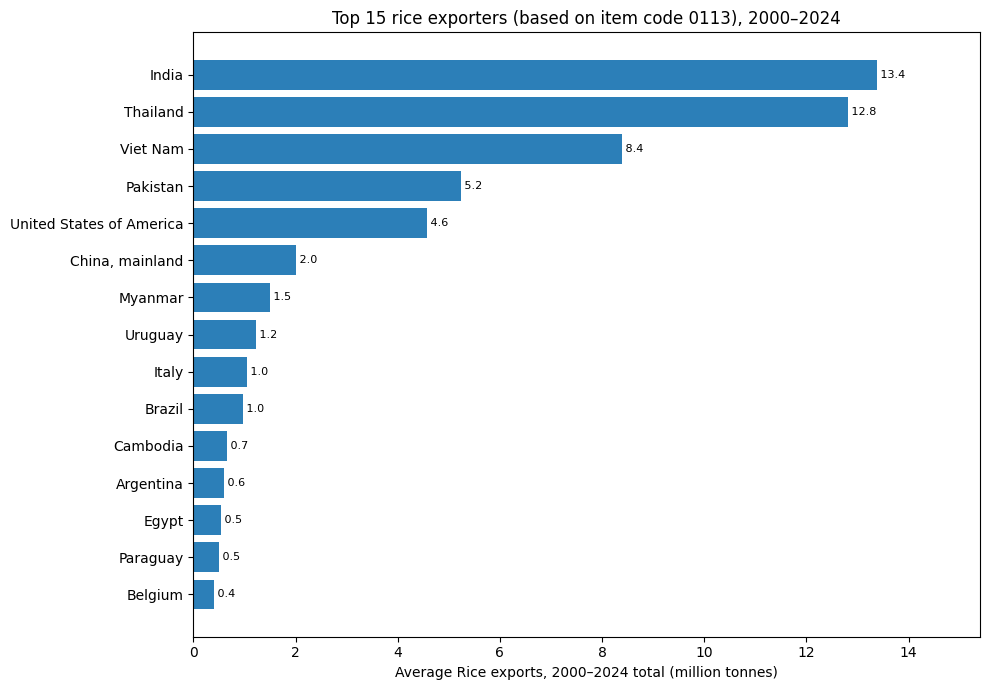

In [26]:
#Plotting the above data in bar chart
top = average_rice_exports_2000_2024.nlargest(15, 'exported_t').sort_values('exported_t')

plt.figure(figsize=(10, 7))
plt.barh(top['Area'], top['exported_t'] / 1e6, color="#2C7FB8")
plt.xlabel("Average Rice exports, 2000–2024 total (million tonnes)")
plt.title("Top 15 rice exporters (based on item code 0113), 2000–2024")

for y, v in enumerate(top['exported_t'] / 1e6):
    plt.text(v, y, f" {v:,.1f}", va='center', fontsize=8)

plt.margins(x=0.15)
plt.tight_layout()
plt.show()

In [27]:
#Adding the world percentage values and ranks in terms of average production
#Similar to the totals above Section 1.b (1.2)
average_rice_exports_2000_2024['pct_of_world'] = (
    average_rice_exports_2000_2024['exported_t']
    / average_rice_exports_2000_2024['exported_t'].sum() * 100
)

average_rice_exports_2000_2024 = average_rice_exports_2000_2024.reset_index(drop=True)
average_rice_exports_2000_2024['rank'] = average_rice_exports_2000_2024.index + 1

print(average_rice_exports_2000_2024)

                         Area  exported_t  pct_of_world  rank
0                       India 13390522.17         23.04     1
1                    Thailand 12820934.13         22.06     2
2                    Viet Nam  8391612.53         14.44     3
3                    Pakistan  5232343.90          9.00     4
4    United States of America  4568268.19          7.86     5
..                        ...         ...           ...   ...
194                     Tonga        0.03          0.00   195
195                   Eritrea        0.02          0.00   196
196                Martinique        0.00          0.00   197
197                Guadeloupe        0.00          0.00   198
198                  RÃ©union        0.00          0.00   199

[199 rows x 4 columns]


### Section 2: Understanding the production vs trade for each country and comparing each

In [28]:
print(rice_production_2000_2024.head())
print(rice_exports_2000_2024.head())

              Area  production_t  pct_share_production  rank
0  China, mainland 4944787500.00                 28.20     1
1            India 3949568648.52                 22.52     2
2        Indonesia 1391403356.54                  7.93     3
3       Bangladesh 1209116494.14                  6.89     4
4         Viet Nam 1004997339.59                  5.73     5
                       Area   exported_t  pct_share_export  rank
0                     India 334763054.16             23.09     1
1                  Thailand 320523353.33             22.11     2
2                  Viet Nam 209790313.16             14.47     3
3                  Pakistan 130808597.52              9.02     4
4  United States of America 114206704.73              7.88     5


# Note on this data analysis:
#### The pct_share_production represents the production share percentage for the country out of the total production
#### The pct_share_export represents the export share percentage for the country out of the total exports

#### Combining the two datasets to see who lies where in production vs export trends

Using full outer join because:
Countries that produce but barely export (China, Indonesia, Bangladesh) and countries that export a lot relative to production. An inner join keeps only countries present in both tables, which quietly drops:

Producers who don't export — if a country grows rice but has no export row, inner join deletes it. That erases the "self-consumer" category (Indonesia, Bangladesh) — the exact finding that makes China's behavior interesting.
Exporters/re-exporters who don't produce — a pure re-exporter (or a country whose production didn't survive filtering) would vanish too.

In [29]:
rice_production_export_c30 = rice_production_2000_2024[
    ['Area', 'production_t', 'pct_share_production', 'rank']
].merge(
    rice_exports_2000_2024[
        ['Area', 'exported_t', 'pct_share_export', 'rank']
    ],
    on='Area',
    how='outer',
    suffixes=('_production', '_export')
)

# a missing side means "none," not "unknown" — fill with 0
rice_production_export_c30['production_t'] = rice_production_export_c30['production_t'].fillna(0)
rice_production_export_c30['exported_t']   = rice_production_export_c30['exported_t'].fillna(0)


rice_production_export_c30 = rice_production_export_c30.rename(columns={
    'rank_production': 'production_rank',
    'rank_export': 'export_rank'
}).sort_values('production_t', ascending=False)

print(rice_production_export_c30.head(20))

                                 Area  production_t  pct_share_production  production_rank   exported_t  \
34                    China, mainland 4944787500.00                 28.20             1.00  50095181.01   
81                              India 3949568648.52                 22.52             2.00 334763054.16   
82                          Indonesia 1391403356.54                  7.93             3.00    117804.04   
12                         Bangladesh 1209116494.14                  6.89             4.00    258194.15   
196                          Viet Nam 1004997339.59                  5.73             5.00 209790313.16   
177                          Thailand  796109925.61                  4.54             6.00 320523353.33   
120                           Myanmar  678686540.00                  3.87             7.00  37501493.88   
139                       Philippines  424852212.51                  2.42             8.00     13793.40   
22                             Brazil

In [30]:
rice_production_export_c30.to_csv('Rice_production_export_c30.csv')

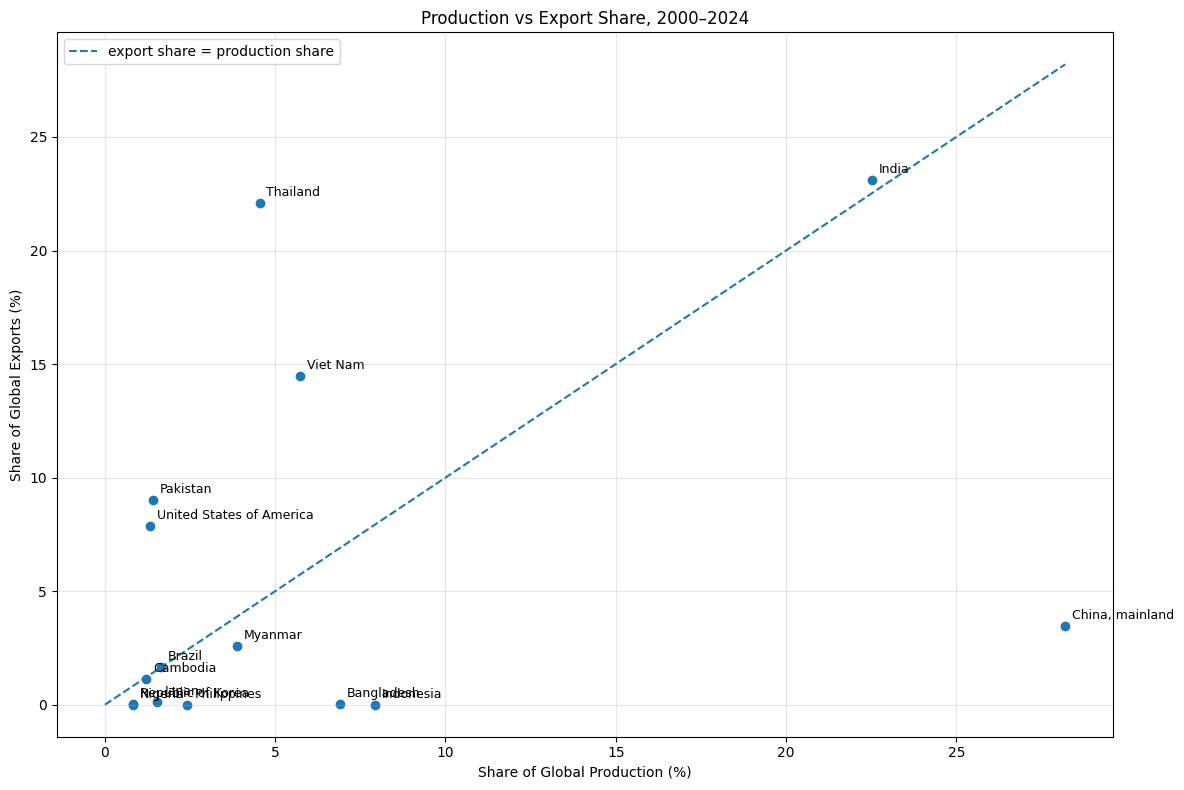

In [31]:
# Your merged production/export dataframe
plot_data = rice_production_export_c30.copy()

# Keep top 10 producers
plot_data = (
    plot_data
    .sort_values('production_t', ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 8))

plt.scatter(
    plot_data['pct_share_production'],
    plot_data['pct_share_export']
)

# Add country labels
for _, row in plot_data.iterrows():
    plt.annotate(
        row['Area'],
        (row['pct_share_production'], row['pct_share_export']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9
    )

# Add diagonal line: export share = production share
max_value = max(
    plot_data['pct_share_production'].max(),
    plot_data['pct_share_export'].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle='--',
    label='export share = production share'
)

plt.xlabel('Share of Global Production (%)')
plt.ylabel('Share of Global Exports (%)')
plt.title('Production vs Export Share, 2000–2024')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Insights here:

**Dual player — grows a lot AND exports a lot (on the diagonal):**

India:
1. Production share = 22.52%
2. Export share     = 23.10%
→ Only country strong on both axes. 2nd-largest producer, #1 exporter. Exports roughly in proportion to its size.

**Export specialists — export far above their production share (above the diagonal):**

Thailand:
1. Production share = 4.54%
2. Export share     = 22.11%
→ Grows little but ships most of it — export share ~5x its production share. A rice economy built for export.

Viet Nam:
1. Production share = 5.73%
2. Export share     = 14.47%
→ Punches ~2.5x above its production weight. Major export-oriented producer.

Pakistan:
1. Production share = 1.41%
2. Export share     = 9.02%
→ Small grower, big supplier — ~6x more export share than production share.

United States of America:
1. Production share = 1.33%
2. Export share     = 7.88%
→ Minor producer, meaningful exporter (~6x its production share). Export-oriented sector.

Myanmar:
1. Production share = 3.87%
2. Export share     = 2.60%
→ Modest producer, slightly export-leaning — sits just below the line.

**Self-consumers — grow enormous volumes, export almost nothing (far below the diagonal):**

China, mainland:
1. Production share = 28.20%
2. Export share     = 3.90%
→ World's largest producer, but keeps nearly all of it. Feeds its own population.

Indonesia:
1. Production share = 7.93%
2. Export share     = 0.01%
→ 3rd-largest producer, essentially zero exports — entirely domestic.

Bangladesh:
1. Production share = 6.89%
2. Export share     = 0.02%
→ 4th-largest producer, negligible trade.

### Takeaway
This chart (top ~15 producers) makes the concentration clearer: production spreads across
many Asian countries, but exports pile into a handful. India uniquely does both; Thailand,
Vietnam, Pakistan, and the USA are pure export specialists sitting well above the line;
China, Indonesia, and Bangladesh are giant self-consumers near the floor. With so few real
suppliers, an export restriction from one (e.g. India, 2022–2023) tightens global supply
fast — the big producers don't sell enough to fill the gap.

The insights above match (approx) with the insights from another rice data analysis file (QCL_all_Rice_Data_code28.ipynb) where the export rice codes used for analysis were codes 28 and 31 vs code 30 here. and as expecetd for reconiliation check, code 30 values are slightly higher than codes 28 and 31 (although similar)




### Section 3: Which Countries Matter for Trade? Export Dependence & Reporter Shortlisting
Export Readiness & Reporter Selection for Bilateral (TM) Analysis

#### Pre-TM Analysis To-Dos
##### Section 3(a)

1. Compute export share of production
export_share = exported_t ÷ production_t, per country.
Why it's essential: Absolute export volume alone is misleading — India and Thailand both export a lot, but Thailand ships most of what it grows while India exports a small slice of an enormous crop. The share tells you which countries are structurally dependent on exporting versus which merely happen to be large. This is the number that predicts how a country will behave in TM: high-share countries are the ones whose outbound flows carry real global supply-chain weight, and whose export bans (like India's) ripple hardest.

In [32]:
trade_df = rice_production_export_c30.copy()

#### Based on the dataframe few trends emerge about production, export and re-export

Data cleanup essentials before computing 1 and 2 above
1. Resolve the zero/null-production rows
59 countries have null production rank and many have production_t = 0; only 141 of 200 actually produce.
Why it's essential: These are outer-join artifacts, and if left unhandled they propagate silently into the TM layer — producing divide-by-zero errors in export share.

2. Flag producers vs. re-exporters
Separate countries that grow rice (production > 0) from those that export without producing (production = 0, exports > 0).
Why it's essential:
A re-exporter is a country that ships out rice it never grew — it bought the rice from another country, then sold it onward to a third country. The rice passes through it, rather than originating there.

The mechanism, step by step:

Country A grows rice (real production).
Country B buys rice from A → this is an import for B.
Country B sells that same rice to Country C → this is an export for B.

In [38]:
#1 —  Compute export share of production + producer/re-exporter classification

REEXPORT_THRESHOLD = 130   # % — export share above this = functionally a re-exporter
                           # (grows a token amount but exports far more than it produces)
                           # This ratio is based on 

# --- Step 1: separate the zero-production countries first ---
producers   = trade_df[trade_df['production_t'] > 0].copy()          # real producers (has crop)
reexporters = trade_df[(trade_df['production_t'] == 0) &
                       (trade_df['exported_t'] > 0)].copy()          # export but don't grow
inactive    = trade_df[(trade_df['production_t'] == 0) &
                       (trade_df['exported_t'] == 0)].copy()         # neither — drop

# --- Step 2: export share, computed only where production > 0 ---
#export_ratio_of_production = what fraction of the rice a country grows that it exports
producers['export_ratio_of_production'] = producers['exported_t'] / producers['production_t'] * 100

# --- Step 3: catch DISGUISED re-exporters ---
# some countries grow a tiny amount but export 10-70x their output (e.g. Saudi Arabia,
# South Africa) — token production let them slip past the ==0 filter. Reclassify by threshold.
disguised = producers[producers['export_ratio_of_production'] > REEXPORT_THRESHOLD].copy()
disguised['note'] = 're-exporter (token production, exports >> output)'

# keep only genuine producers (export share within a plausible range)
producers = producers[producers['export_ratio_of_production'] <= REEXPORT_THRESHOLD].copy()

# --- Step 4: label the true re-exporters (zero-production) and fold in the disguised ones ---
reexporters['export_ratio_of_production'] = pd.NA
reexporters['note'] = 're-exporter (no domestic production)'
reexporters = pd.concat([reexporters, disguised], ignore_index=True)

# --- Step 5: label the inactive countries ---
inactive['export_ratio_of_production'] = pd.NA
inactive['note'] = 'neither produces nor exports'

# --- sanity checks ---
print(f"producers:   {len(producers)}")
print(f"re-exporters: {len(reexporters)}  (zero-production + disguised)")
print(f"inactive:    {len(inactive)}")
print("\nDisguised re-exporters moved out of producers:")
print(disguised[['Area', 'production_t', 'exported_t', 'export_ratio_of_production']].to_string(index=False))
print("\nGenuine producers with export share > 100% (legit stock/re-export):")
print(producers[producers['export_ratio_of_production'] > 100]
      [['Area', 'production_t', 'exported_t', 'export_ratio_of_production']].to_string(index=False))

producers:   116
re-exporters: 82  (zero-production + disguised)
inactive:    2

Disguised re-exporters moved out of producers:
        Area  production_t  exported_t  export_ratio_of_production
South Africa      77110.62  2718949.97                     3526.04
Saudi Arabia       4747.75   329623.73                     6942.74
   Mauritius       4188.00    88032.69                     2102.02
     Jamaica       1296.30     4703.40                      362.83

Genuine producers with export share > 100% (legit stock/re-export):
    Area  production_t  exported_t  export_ratio_of_production
  France    2378049.40  2508587.60                      105.49
Bulgaria    1181146.00  1476059.55                      124.97


/var/folders/1r/6nts2hsj4tbdxxzj39hbr34r0000gn/T/ipykernel_90849/3757565369.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  reexporters = pd.concat([reexporters, disguised], ignore_index=True)


In [39]:
# --- Combine into one labelled frame ---
producers['category']   = 'producer'
reexporters['category']  = 're-exporter'
inactive['category']     = 'inactive'

trade_classified = pd.concat([producers, reexporters, inactive], ignore_index=True)

# drop the note column — category already carries the classification
trade_classified = trade_classified.drop(columns='note', errors='ignore')

print(trade_classified['category'].value_counts())
print(f"total countries: {len(trade_classified)}")

category
producer       116
re-exporter     82
inactive         2
Name: count, dtype: int64
total countries: 200


/var/folders/1r/6nts2hsj4tbdxxzj39hbr34r0000gn/T/ipykernel_90849/3238620066.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  trade_classified = pd.concat([producers, reexporters, inactive], ignore_index=True)


In [40]:
trade_classified

,Area,production_t,pct_share_production,production_rank,exported_t,pct_share_export,export_rank,export_ratio_of_production,category
0,"China, mainland",4944787500.00,28.20,1.00,50095181.01,3.46,6.00,1.01,producer
1,India,3949568648.52,22.52,2.00,334763054.16,23.09,1.00,8.48,producer
2,Indonesia,1391403356.54,7.93,3.00,117804.04,0.01,71.00,0.01,producer
3,Bangladesh,1209116494.14,6.89,4.00,258194.15,0.02,58.00,0.02,producer
4,Viet Nam,1004997339.59,5.73,5.00,209790313.16,14.47,3.00,20.87,producer
...,...,...,...,...,...,...,...,...,...
195,Saudi Arabia,4747.75,0.00,116.00,329623.73,0.02,55.00,6942.74,re-exporter
196,Mauritius,4188.00,0.00,117.00,88032.69,0.01,78.00,2102.02,re-exporter
197,Jamaica,1296.30,0.00,119.00,4703.40,0.00,140.00,362.83,re-exporter
198,Guadeloupe,0.00,NaN,NaN,0.00,0.00,197.00,NaN,inactive


#### Section Selecting Reporter Countries for the Trade-Flow (TM) Analysis

**What this does:** Narrows the full country list down to a shortlist of major, genuine
rice exporters that are worth mapping in the bilateral Detailed Trade Matrix (TM) — the
"who ships to whom" layer.

**Why it's needed:** TM data explodes into reporter × partner pairs (every exporter against
every buyer), so mapping all 200 countries is neither feasible nor meaningful — most would
be noise. We need a small, defensible set of reporters that actually drive world rice trade.

**The selection rule (three filters):**
1. `category == 'producer'` — keep only true sources. Excludes re-exporters (e.g. Saudi
   Arabia, South Africa) so we don't mis-attribute the *origin* of rice they merely
   pass through.
2. `exported_t > 1 Mt` — keep only meaningful volumes. Drops trivial exporters whose
   bilateral flows would be statistical noise.
3. `export_ratio_of_production > 5%` — keep only genuinely export-*oriented* countries

**Result:** a reproducible reporter shortlist (expected: India, Thailand, Vietnam, Pakistan,
USA, Myanmar, Cambodia, Brazil) that feeds the next layer — mapping each exporter's top
destination markets and the dependency of importing countries on them.

In [41]:
# only genuine producers that are real, export-oriented exporters
shortlist = trade_classified[
    (trade_classified['category'] == 'producer') &   # true sources, not re-exporters
    (trade_classified['exported_t'] > 1e6) &         # meaningful volume (>1 Mt paddy-eq)
    (trade_classified['export_ratio_of_production'] > 5)       # actually export-oriented, 5 is set arbitarily right now, can be updated
].sort_values('exported_t', ascending=False)

print(shortlist[['Area', 'exported_t', 'export_ratio_of_production',
                 'pct_share_export', 'export_rank']].to_string(index=False))
print(f"\n{len(shortlist)} reporters selected for TM analysis")

                       Area   exported_t  export_ratio_of_production  pct_share_export  export_rank
                      India 334763054.16                        8.48             23.09         1.00
                   Thailand 320523353.33                       40.26             22.11         2.00
                   Viet Nam 209790313.16                       20.87             14.47         3.00
                   Pakistan 130808597.52                       53.08              9.02         4.00
   United States of America 114206704.73                       48.87              7.88         5.00
                    Myanmar  37501493.88                        5.53              2.59         7.00
                    Uruguay  30443529.48                       96.06              2.10         8.00
                      Italy  26059725.61                       71.78              1.80         9.00
                     Brazil  24260079.39                        8.42              1.67        10.00


#### Using the list of countries from above for TM (reporter/partner) analysis that feeds to water stress analysis

In [42]:
BULK_URL = 'https://bulks-faostat.fao.org/production/Trade_DetailedTradeMatrix_E_All_Data_(Normalized).zip'
if not os.path.exists('tm_bulk.zip'):
    print('Downloading TM bulk (~400 MB zip / ~1.5 GB unzipped)...')
    urllib.request.urlretrieve(BULK_URL, 'tm_bulk.zip')

# REPORTERS = ['India', 'Thailand', 'Viet Nam', 'Pakistan', 'United States of America',
#              'Myanmar', 'Uruguay', 'Italy', 'Brazil', 'Cambodia', 'Argentina', 'Egypt',
#              'Paraguay', 'Spain', 'Guyana', 'Australia', 'United Republic of Tanzania',
#              'Russian Federation', 'Greece', 'Türkiye', 'Senegal', 'France', 'Kazakhstan',
#              'Niger', 'Portugal', 'Suriname', 'Bulgaria', 'Benin', 'Uganda']

REPORTERS = shortlist['Area'].tolist()

ITEM_CODES = [30]              # code 30 (consistent with your pipeline); switch to [28,31] if 30 is empty
ELEMENTS   = [5910]           # Export quantity (reporter's exports TO each partner)
YEAR_MIN, YEAR_MAX = 2000, 2024

with zipfile.ZipFile('tm_bulk.zip') as z:
    def is_meta(n):
        low = n.lower().replace('_', '')
        return any(k in low for k in ('flags', 'itemcodes', 'elements',
                                      'countrycodes', 'areacodes'))
    csv_name = [n for n in z.namelist() if n.endswith('.csv') and not is_meta(n)][0]
    print(f'Streaming {csv_name}...')

    parts = []
    for chunk in pd.read_csv(z.open(csv_name), encoding='latin-1',
                             low_memory=False, chunksize=1_000_000):
        chunk.columns = [c.strip() for c in chunk.columns]
        chunk['Item Code']    = pd.to_numeric(chunk['Item Code'], errors='coerce')
        chunk['Element Code'] = pd.to_numeric(chunk['Element Code'], errors='coerce')
        chunk['Year']         = pd.to_numeric(chunk['Year'], errors='coerce')

        m = (
            chunk['Reporter Countries'].isin(REPORTERS)
            & chunk['Item Code'].isin(ITEM_CODES)
            & chunk['Element Code'].isin(ELEMENTS)
            & chunk['Year'].between(YEAR_MIN, YEAR_MAX)
        )
        if m.any():
            parts.append(chunk.loc[m])

    if not parts:
        raise ValueError("No rows matched — check reporter spelling / item code coverage.")
    tm_rice = pd.concat(parts, ignore_index=True)

# --- confirm every reporter was actually found (catches spelling/encoding drops) ---
found = set(tm_rice['Reporter Countries'].unique())
missing = [r for r in REPORTERS if r not in found]
print(f"\nrows: {len(tm_rice):,}   reporters found: {len(found)}/{len(REPORTERS)}")
if missing:
    print("!! not found (check spelling in the TM file):", missing)

Streaming Trade_DetailedTradeMatrix_E_All_Data_(Normalized).csv...

rows: 33,044   reporters found: 29/29


##### Caveat: 
Since this notebook is looking at code 30, most of these values are converted and hence will have only Export values as Estimated

In [43]:
print(((tm_rice['Flag'] == 'A') | (tm_rice['Flag'] == 'I')).any())

False


#### Who buys how much from each related table:

In [44]:
# total export quantity from each reporter to each partner, 2000-2024
flows = (tm_rice.groupby(['Reporter Countries', 'Partner Countries'])['Value']
                .sum().reset_index(name='export_qty_t'))

# print(flows.head())

# top 25 buyers for each reporter
top_buyers = (flows.sort_values(['Reporter Countries', 'export_qty_t'], ascending=[True, False])
                   .groupby('Reporter Countries').head(25))


In [45]:
# total export quantity from each reporter to each partner, 2000-2024
flows = (tm_rice.groupby(['Reporter Countries', 'Partner Countries'])['Value']
                .sum().reset_index(name='export_qty_t'))

# each partner's total imports from your reporter set (the denominator)
partner_totals = (flows.groupby('Partner Countries')['export_qty_t']
                       .transform('sum'))

# dependency: what share of this partner's imports (from your reporters) come from this reporter
flows['dependency_pct'] = (flows['export_qty_t'] / partner_totals * 100).round(1)

flows['export_qty_t'] = (flows['export_qty_t'] / 1e6).round(2)

# sort by flow size, then dependency, both descending
flows = flows.sort_values(['export_qty_t', 'dependency_pct'],
                          ascending=[False, False]).reset_index(drop=True)

print(flows.head(30).to_string(index=False))
# print(flows.to_string(index=False))

      Reporter Countries          Partner Countries  export_qty_t  dependency_pct
                   India               Saudi Arabia         21.68           71.80
                Viet Nam                Philippines         19.18           62.00
                Viet Nam            China, mainland         17.99           35.30
                Thailand                      Benin         15.27           48.50
                   India Iran (Islamic Republic of)         14.98           61.50
                Thailand               South Africa         14.71           64.20
                   India                 Bangladesh         14.38           81.60
                Thailand                    Nigeria         13.95           66.80
                   India                      Benin         13.51           42.90
United States of America                     Mexico         13.26           84.40
                Thailand            China, mainland         13.23           26.00
                

In [46]:
#Individual country analysis
print(flows[flows['Reporter Countries'] == 'Viet Nam']
      .sort_values('dependency_pct', ascending=False)
      [['Partner Countries', 'export_qty_t', 'dependency_pct']].to_string(index=False))

                                   Partner Countries  export_qty_t  dependency_pct
                                             Vanuatu          0.04           78.90
                                     Solomon Islands          0.07           72.80
                                         Philippines         19.18           62.00
                                    Marshall Islands          0.02           58.50
                                               Ghana          5.30           45.00
                                            Kiribati          0.02           42.50
                                         Timor-Leste          0.40           35.60
                                     China, mainland         17.99           35.30
                                                Fiji          0.16           28.70
                                            Malaysia          5.70           28.50
                                            Cambodia          0.18           28.10
    

In [47]:
# each partner's total imports FROM the reporter set (not using impoter value specifically)
partner_totals = (flows.groupby('Partner Countries')['export_qty_t']
                       .sum().reset_index(name='partner_total_from_reporters'))

# join back and compute dependency share
dependency = flows.merge(partner_totals, on='Partner Countries')
dependency['dependency_pct'] = (
    dependency['export_qty_t'] / dependency['partner_total_from_reporters'] * 100
).round(1)

# sort so each buyer's biggest supplier is on top
dependency = dependency.sort_values(
    ['Partner Countries', 'dependency_pct'], ascending=[True, False]
).reset_index(drop=True)
dependency.to_csv('Reporter_Partner_Export_Dependency.csv', columns=['Partner Countries', 'Reporter Countries',
                  'export_qty_t', 'dependency_pct'])
print(dependency[['Partner Countries', 'Reporter Countries',
                  'export_qty_t', 'dependency_pct']].to_string(index=False))

                                   Partner Countries          Reporter Countries  export_qty_t  dependency_pct
                                         Afghanistan                    Pakistan          6.87           98.00
                                         Afghanistan                     Myanmar          0.06            0.90
                                         Afghanistan                       India          0.03            0.40
                                         Afghanistan    United States of America          0.03            0.40
                                         Afghanistan                  Kazakhstan          0.01            0.10
                                         Afghanistan                       Italy          0.01            0.10
                                         Afghanistan                      Brazil          0.00            0.00
                                         Afghanistan                      France          0.00            0.00
 

In [48]:
understand_Water_risk_reporter = sorted(flows['Reporter Countries'].unique().tolist())
understand_Water_risk_partner  = sorted(flows['Partner Countries'].unique().tolist())

print(f"reporters ({len(understand_Water_risk_reporter)}):")
print(understand_Water_risk_reporter)
print(f"\npartners ({len(understand_Water_risk_partner)}):")
print(understand_Water_risk_partner)

#common = sorted(set(understand_Water_risk_reporter) & set(understand_Water_risk_partner))
# print(f"{len(common)} countries appear as BOTH exporter and buyer:")
# print(common)
# 29 countries appear as BOTH exporter and buyer:
# ['Argentina', 'Australia', 'Benin', 'Brazil', 'Bulgaria', 'Cambodia', 'Egypt', 'France', 'Greece', 'Guyana', 'India', 'Italy', 'Kazakhstan', 'Myanmar', 'Niger', 'Pakistan', 'Paraguay', 'Portugal', 'Russian Federation', 'Senegal', 'Spain', 'Suriname', 'Thailand', 'TÃ¼rkiye', 'Uganda', 'United Republic of Tanzania', 'United States of America', 'Uruguay', 'Viet Nam']

reporters (29):
['Argentina', 'Australia', 'Benin', 'Brazil', 'Bulgaria', 'Cambodia', 'Egypt', 'France', 'Greece', 'Guyana', 'India', 'Italy', 'Kazakhstan', 'Myanmar', 'Niger', 'Pakistan', 'Paraguay', 'Portugal', 'Russian Federation', 'Senegal', 'Spain', 'Suriname', 'Thailand', 'TÃ¼rkiye', 'Uganda', 'United Republic of Tanzania', 'United States of America', 'Uruguay', 'Viet Nam']

partners (200):
['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia (Plurinational State of)', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada', 'Central African Republic', 'Chad', 'Chile', 'China, Hong Kong SAR', 'China, Macao SAR', 'China, Taiwan Province of', 'China, mainland', 'Colombia', 'Comoros', 'Congo', 'Cook I

#### Up next Heidi to understand water risk/indicator for countries:

TODO:
For Heidi: Use list understand_Water_risk_reporter  and understand_Water_risk_partner to understand the virtual water risk 

For us: Use this data to merge with the dependency df to understand the risk and the dependency_pct together and associate the risk